In [1]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa, h_r_recursive_cpa
from matplotlib.pyplot import imshow
import matplotlib.cm as cm
from matplotlib.pyplot import contourf

# We check that if we use the multilayer formalism for a finite thickness (with thickness d) thin film, our closed-form solutions for an infinitely thin coating hold in the limit $d\rightarrow 0$

In [2]:
# Finding the closed form conductivities:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [3]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_real_closed_form = sigmas[0, :]
sigmas_imaginary_closed_form = sigmas[1, :]

In [7]:
N, M, K = 200, 200, 100
l = 1
kRs = linspace(0.02, 1, K)
kd_ratios = [0.01, 0.1, 0.2, 0.3]
scattering_amplitudes_v_v = []
epsilon1 = 2.1*np.ones((N, M)) # Take a fixed dielectric constant for silica 
epsilon2 = np.ones((N, M)) 
sigma_real = linspace(0, 1.5, N).reshape((N, 1)).repeat(M, axis=1)
sigma_imaginary = linspace(0, 3, M).reshape((1, M)).repeat(N, axis=0)

In [8]:
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    kds = kd_ratio*kRs
    scattering_amplitudes_v = []
    
    for (kR_idx, (kR, kd)) in enumerate(zip(kRs, kds)):
        if kR_idx % 25 == 0:
            print("kR_idx: ", kR_idx); 
        previous_coefficients = np.array([1, 1])
        
        epsilon_thin_film = 1 + 1j*(sigma_real + 1j*sigma_imaginary)/(kd)
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon_thin_film, (kR-kd/2)*ones((N, M)))
        
        # The dielectric constant will be depend on the thickness: epsilon = 1+ i*sigma/(omega*epsilon_0*d)
        # If we write this in terms of normalized conductivities, simga_primes, (in units of c*epsilon_0), we obtain
        # epsilon = 1+ i*sigma_prime/(omega*d/c) = 1+ i*sigma_prime/(k*d)
        # Therefore, the only free parameters are the unitless quantities, kR and kd. 
        
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon_thin_film, epsilon2, (kR+kd/2)*ones((N, M)))
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        scattering_amplitudes_v.append(scattering_amplitudes)
    scattering_amplitudes_v_v.append(scattering_amplitudes_v)

kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75


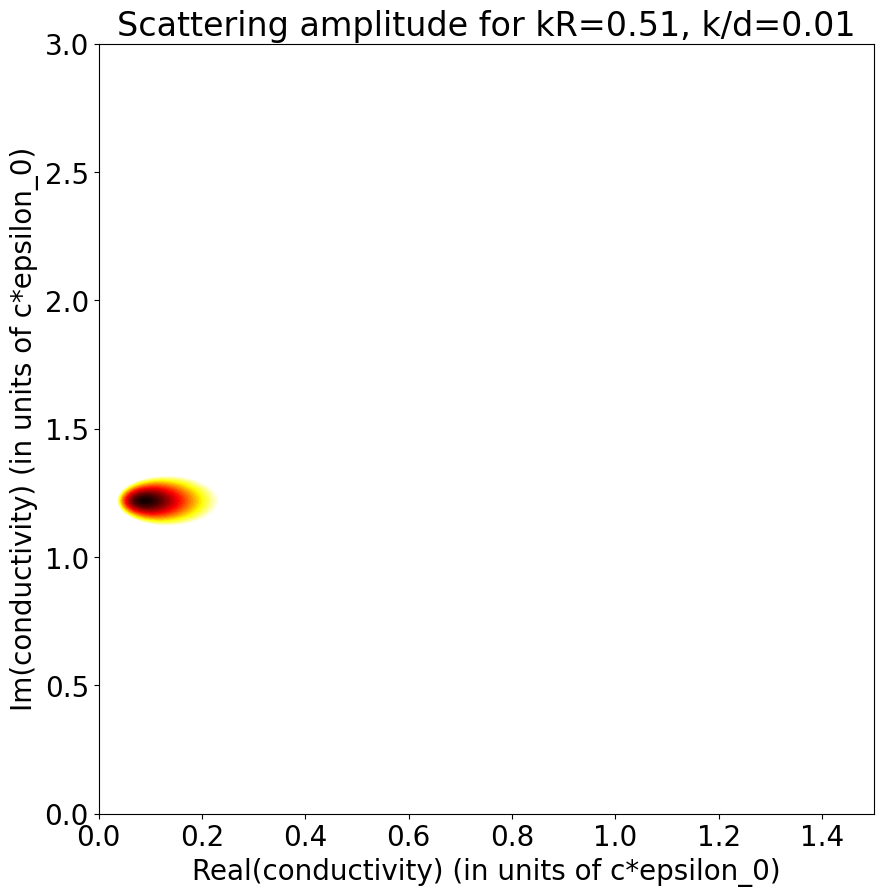

In [16]:
plt.rcParams.update({'font.size': 20})
kd_ratio_idx = 0
kR_idx = 50
fig, ax = plt.subplots(figsize=(10, 10))
ax.contourf(sigma_real, sigma_imaginary, scattering_amplitudes_v_v[kd_ratio_idx][kR_idx], levels=200, cmap="hot", vmin=0, vmax=0.2)
ax.set_xlabel("Real(conductivity) (in units of c*epsilon_0)");
ax.set_ylabel("Im(conductivity) (in units of c*epsilon_0)");
ax.set_title(f"Scattering amplitude for kR={round(kRs[kR_idx], 2)}, k/d={kd_ratios[kd_ratio_idx]}")
ax.set_xlim(0, 1.5);

In [17]:
argmin_indices = [[scattering_amplitudes_v[idx].argmin() for idx in range(0, 100)] for scattering_amplitudes_v in scattering_amplitudes_v_v]
flattened_sigma_real = sigma_real.flatten()
flattened_sigma_imaginary = sigma_imaginary.flatten()

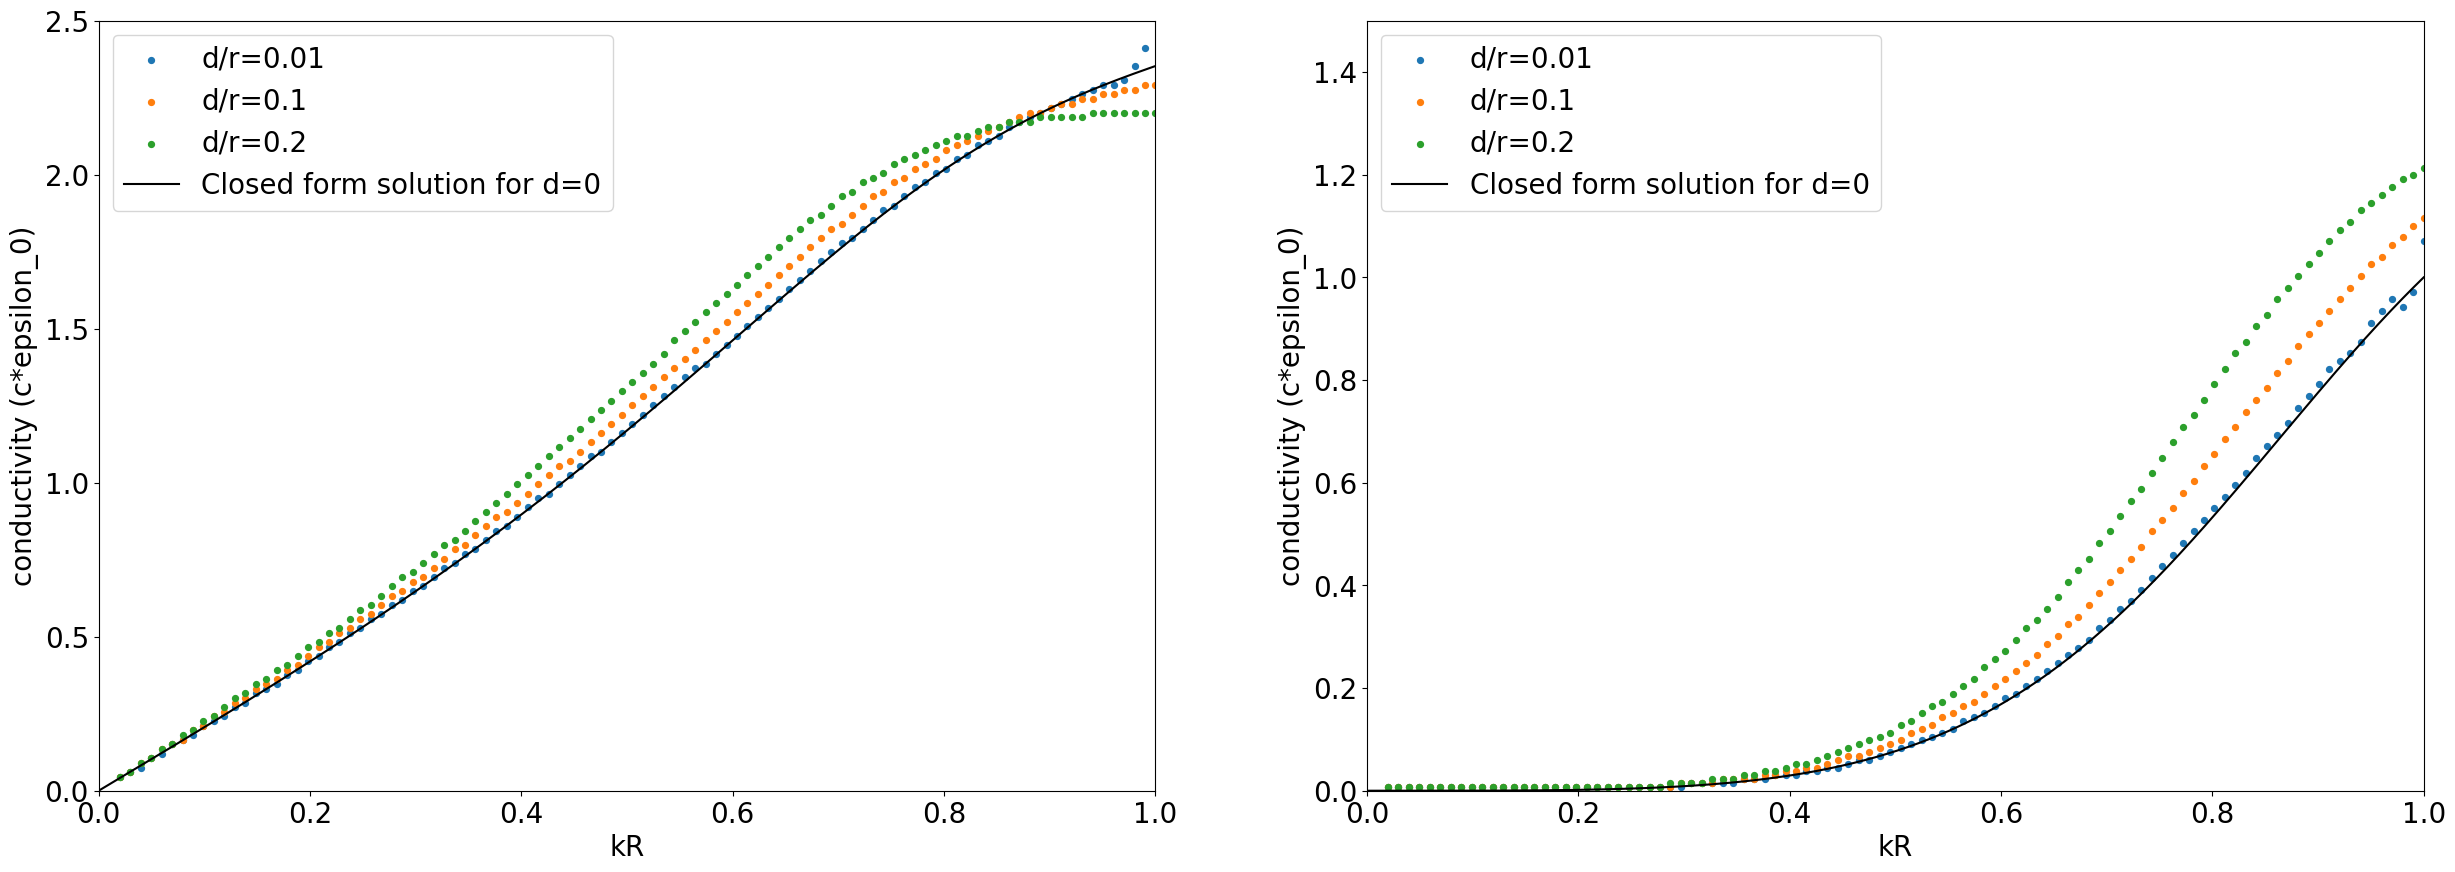

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios[0:3]):
    ax1.scatter(kRs, flattened_sigma_imaginary[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=5)
    ax2.scatter(kRs, flattened_sigma_real[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=5)
ax1.plot(x, sigmas_imaginary_closed_form, color="black", label="Closed form solution for d=0")
ax2.plot(x, sigmas_real_closed_form, color="black", label="Closed form solution for d=0")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 2.5)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.5);
ax1.set_xlabel("kR")
ax2.set_xlabel("kR")
ax1.set_ylabel("conductivity (c*epsilon_0)")
ax2.set_ylabel("conductivity (c*epsilon_0)")
ax1.legend()
ax2.legend();

# Now we do the same thing for the magnetic modes

In [33]:
M = 1000
epsilon = 12
x_1 = 0.5
x_2 = 1
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [34]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_real_closed_form = sigmas[0, :]
sigmas_imaginary_closed_form = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

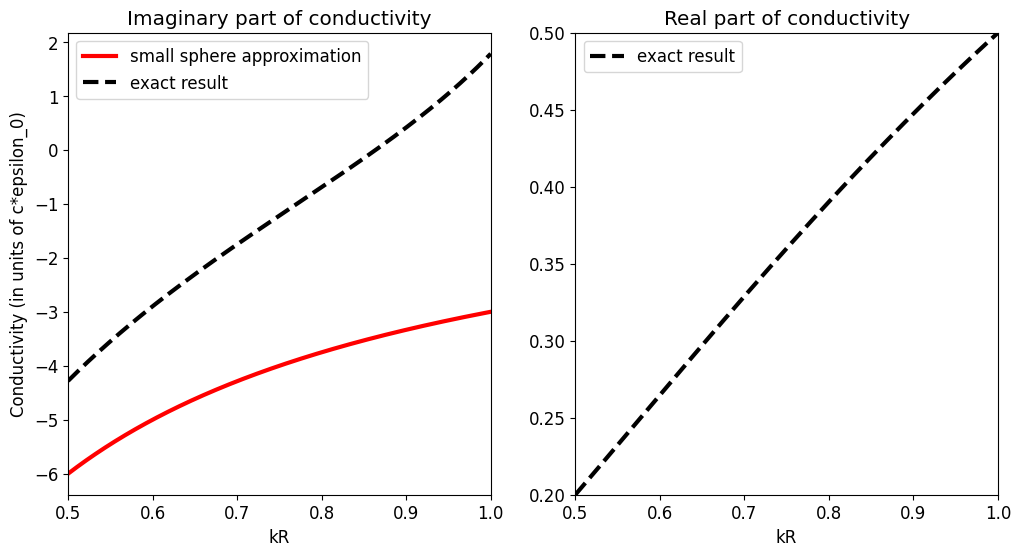

In [30]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_sphere_dispersion, label="small sphere approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigmas_imaginary_closed_form, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax2.set_ylim(sigmas_imaginary_closed_form.min(), sigmas_imaginary_closed_form.max())
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigmas_real_closed_form, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(sigmas_real_closed_form.min(), sigmas_real_closed_form.max())
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();

In [91]:
N, M, K = 200, 200, 100
l = 1
kRs = linspace(0.5, 1, K)
kd_ratios = [0.025, 0.1, 0.2, 0.3]
scattering_amplitudes_v_v = []
epsilon1 = 12*np.ones((N, M)) # Take a fixed dielectric constant for silica 
epsilon2 = np.ones((N, M)) 
sigma_real = linspace(0.15, 0.6, N).reshape((N, 1)).repeat(M, axis=1)
sigma_imaginary = linspace(-6, 2, M).reshape((1, M)).repeat(N, axis=0)

In [92]:
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios):
    kds = kd_ratio*kRs
    scattering_amplitudes_v = []
    
    for (kR_idx, (kR, kd)) in enumerate(zip(kRs, kds)):
        if kR_idx % 25 == 0:
            print("kR_idx: ", kR_idx); 
        previous_coefficients = np.array([1, 1])
        
        epsilon_thin_film = 1 + 1j*(sigma_real + 1j*sigma_imaginary)/(kd)
        next_coefficients = h_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon_thin_film, (kR-kd/2)*ones((N, M)))
        
        # The dielectric constant will be depend on the thickness: epsilon = 1+ i*sigma/(omega*epsilon_0*d)
        # If we write this in terms of normalized conductivities, simga_primes, (in units of c*epsilon_0), we obtain
        # epsilon = 1+ i*sigma_prime/(omega*d/c) = 1+ i*sigma_prime/(k*d)
        # Therefore, the only free parameters are the unitless quantities, kR and kd. 
        
        next_coefficients = h_r_recursive_cpa(next_coefficients, l, epsilon_thin_film, epsilon2, (kR+kd/2)*ones((N, M)))
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        scattering_amplitudes_v.append(scattering_amplitudes)
    scattering_amplitudes_v_v.append(scattering_amplitudes_v)

kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75
kR_idx:  0
kR_idx:  25
kR_idx:  50
kR_idx:  75


In [93]:
argmin_indices = [[scattering_amplitudes_v[idx].argmin() for idx in range(0, K)] for scattering_amplitudes_v in scattering_amplitudes_v_v]
flattened_sigma_real = sigma_real.flatten()
flattened_sigma_imaginary = sigma_imaginary.flatten()

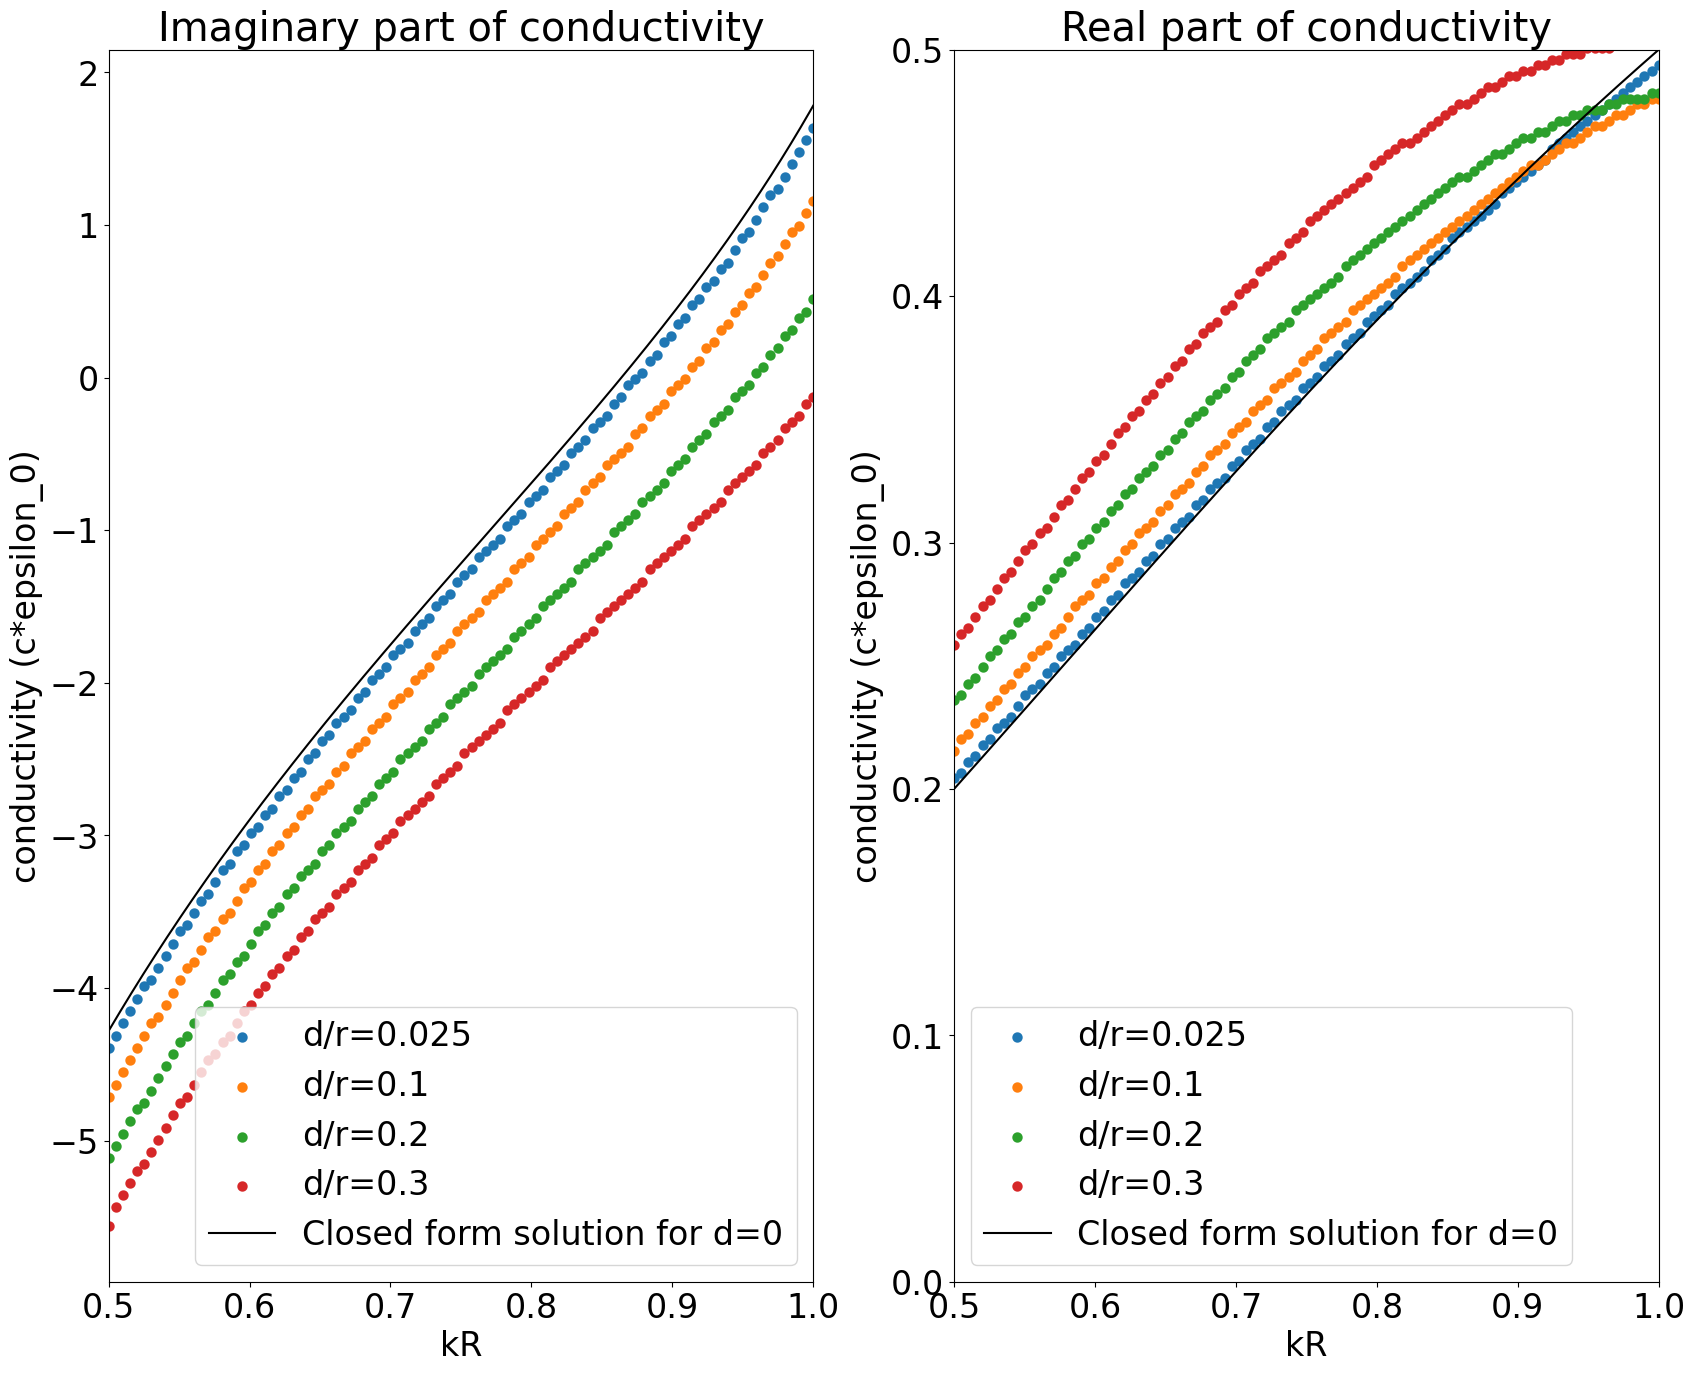

In [95]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 16))
for (kd_ratio_idx, kd_ratio) in enumerate(kd_ratios[0:4]):
    ax1.scatter(kRs, flattened_sigma_imaginary[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=20)
    ax2.scatter(kRs, flattened_sigma_real[argmin_indices[kd_ratio_idx]], linewidth=3, label=f"d/r={kd_ratio}", s=20)
ax1.plot(x, sigmas_imaginary_closed_form, color="black", label="Closed form solution for d=0")
ax2.plot(x, sigmas_real_closed_form, color="black", label="Closed form solution for d=0")
ax1.set_xlim(x_1, x_2)
#ax1.set_ylim(0, 2.5)
ax2.set_xlim(x_1, x_2)
ax2.set_ylim(0, 0.5);
ax1.set_xlabel("kR")
ax2.set_xlabel("kR")
ax1.set_ylabel("conductivity (c*epsilon_0)")
ax2.set_ylabel("conductivity (c*epsilon_0)")
ax1.legend()
ax2.legend();
ax1.set_title("Imaginary part of conductivity")
ax2.set_title("Real part of conductivity");